In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from src.stochastic_sir import run_stochastic_sir
from src.deterministic_sir import run_deterministic_sir
from src.ml_model import SIRNet

In [3]:
import os

print("Files inside results folder:")
print(os.listdir("../results"))

Files inside results folder:
['deterministic_sir.npz', 'sir_nn_model.pt', 'stochastic_means.npz']


In [4]:
data = np.load("../results/stochastic_means.npz")

t = data["t"]
S = data["S"]
I = data["I"]
R = data["R"]

print("Shapes:")
print("t:", t.shape)
print("S:", S.shape)
print("I:", I.shape)
print("R:", R.shape)

Shapes:
t: (161,)
S: (161,)
I: (161,)
R: (161,)


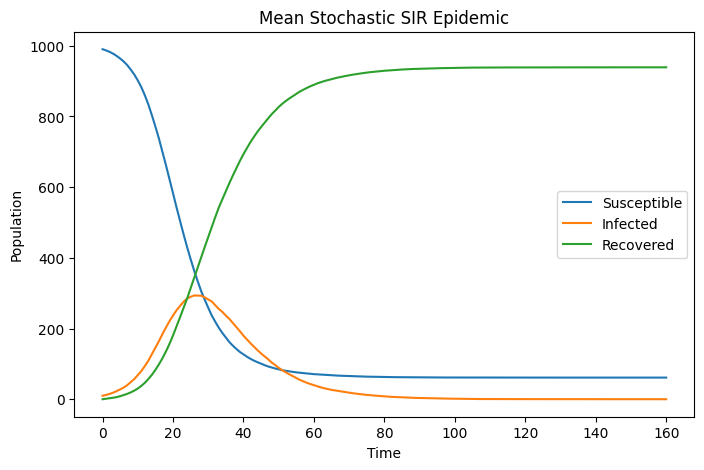

In [5]:
plt.figure(figsize=(8,5))

plt.plot(t, S, label="Susceptible")
plt.plot(t, I, label="Infected")
plt.plot(t, R, label="Recovered")

plt.xlabel("Time")
plt.ylabel("Population")
plt.title("Mean Stochastic SIR Epidemic")

plt.legend()
plt.show()

In [6]:
t_d, S_d, I_d, R_d = run_deterministic_sir()

print("Deterministic shapes:", t_d.shape)

Deterministic shapes: (161,)


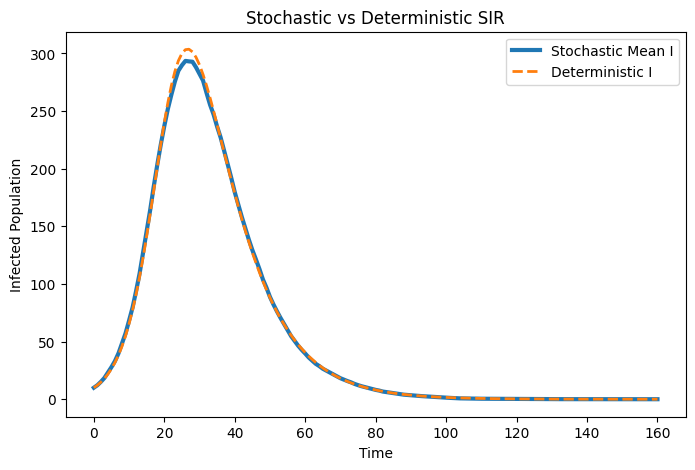

In [7]:
plt.figure(figsize=(8,5))

plt.plot(t, I, label="Stochastic Mean I", linewidth=3)
plt.plot(t_d, I_d, "--", label="Deterministic I", linewidth=2)

plt.xlabel("Time")
plt.ylabel("Infected Population")
plt.title("Stochastic vs Deterministic SIR")

plt.legend()
plt.show()

In [8]:
from src.ml_model import SIRNet
import torch

model = SIRNet()
model.load_state_dict(torch.load("../results/sir_nn_model.pt"))

model.eval()

SIRNet(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=3, bias=True)
    (7): Sigmoid()
  )
)

In [9]:
t_norm = t / t.max()

t_tensor = torch.tensor(t_norm, dtype=torch.float32).view(-1,1)

pred = model(t_tensor).detach().numpy()

S_pred = pred[:,0]
I_pred = pred[:,1]
R_pred = pred[:,2]

print("Prediction sample:")
print(pred[:5])

Prediction sample:
[[0.98565894 0.01226394 0.00375728]
 [0.9824552  0.01464751 0.00464681]
 [0.97854084 0.01747538 0.0057484 ]
 [0.97377646 0.02083768 0.00710926]
 [0.96798897 0.02483052 0.00878945]]


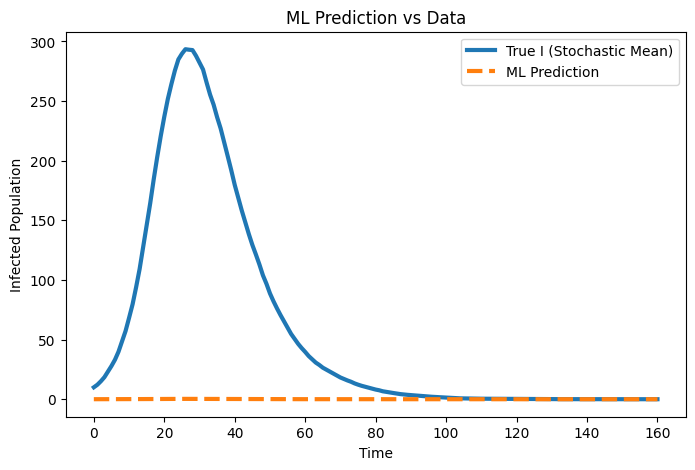

In [10]:
plt.figure(figsize=(8,5))

plt.plot(t, I, label="True I (Stochastic Mean)", linewidth=3)
plt.plot(t, I_pred, "--", label="ML Prediction", linewidth=3)

plt.xlabel("Time")
plt.ylabel("Infected Population")
plt.title("ML Prediction vs Data")

plt.legend()
plt.show()

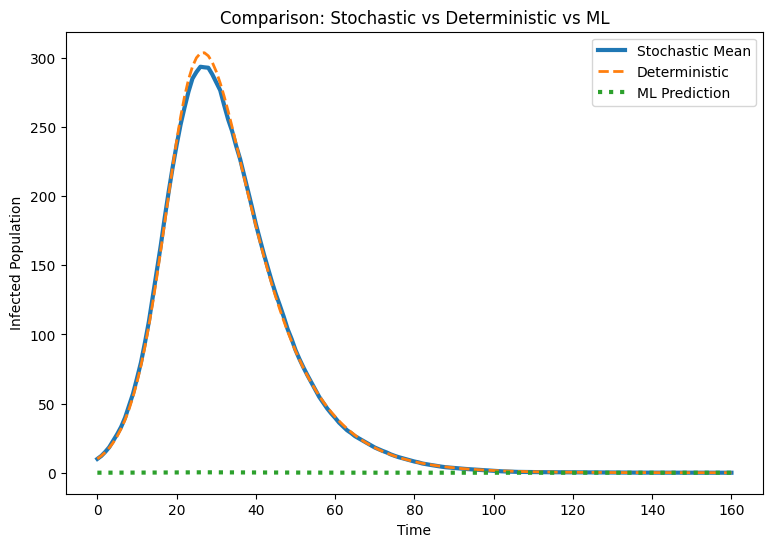

In [11]:
plt.figure(figsize=(9,6))

plt.plot(t, I, label="Stochastic Mean", linewidth=3)
plt.plot(t_d, I_d, "--", label="Deterministic", linewidth=2)
plt.plot(t, I_pred, ":", label="ML Prediction", linewidth=3)

plt.xlabel("Time")
plt.ylabel("Infected Population")
plt.title("Comparison: Stochastic vs Deterministic vs ML")

plt.legend()
plt.show()

In [12]:
from src.ml_model import SIRNet
import torch

model = SIRNet()
model.load_state_dict(torch.load("../results/sir_nn_model.pt"))
model.eval()

SIRNet(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=3, bias=True)
    (7): Sigmoid()
  )
)

In [13]:
t_norm = t / t.max()

t_tensor = torch.tensor(t_norm, dtype=torch.float32).view(-1,1)

pred = model(t_tensor).detach().numpy()

In [14]:
print(pred[:5])

[[0.98565894 0.01226394 0.00375728]
 [0.9824552  0.01464751 0.00464681]
 [0.97854084 0.01747538 0.0057484 ]
 [0.97377646 0.02083768 0.00710926]
 [0.96798897 0.02483052 0.00878945]]


In [15]:
N = 1000

S_pred = pred[:,0] * N
I_pred = pred[:,1] * N
R_pred = pred[:,2] * N

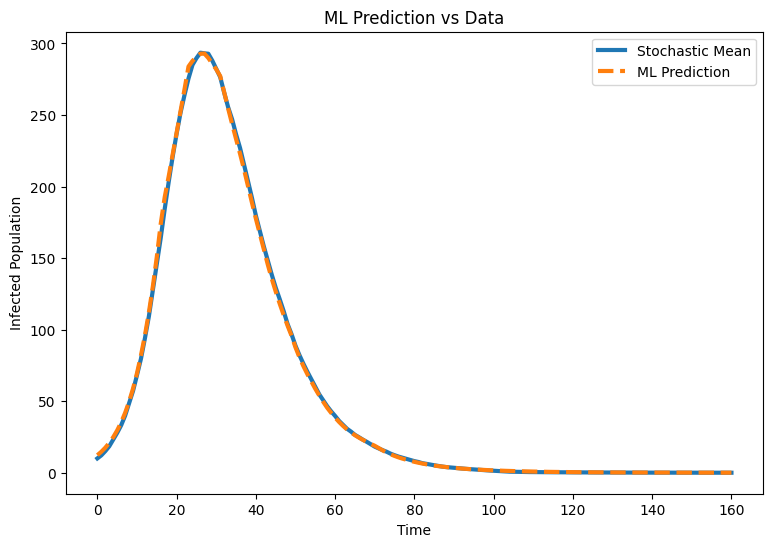

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,6))

plt.plot(t, I, label="Stochastic Mean", linewidth=3)
plt.plot(t, I_pred, "--", label="ML Prediction", linewidth=3)

plt.xlabel("Time")
plt.ylabel("Infected Population")
plt.title("ML Prediction vs Data")

plt.legend()
plt.show()